# Women's Clothing E-Commerce Review Sentiment Analysis

**Dataset:** Women's Clothing E-Commerce Reviews (23,486 customer reviews) — includes review text, star rating (1–5), and product metadata.

**Objective:** Predict customer sentiment directly from free-text reviews.

**Target classes (3-class problem):**
| Rating | Sentiment |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |

**Pipeline:**

`Data Loading → Data Cleaning → EDA → Text Preprocessing → Train/Test Split → TF-IDF → Imbalance Handling → Multiple ML Models → Evaluation → Model Comparison → Best Model`

This is a **three-class classification problem** — the Neutral class is kept throughout.

## 2. Imports & Setup
Core libraries for data handling, text processing, visualization, and modeling. Random seed fixed for reproducibility.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

from imblearn.over_sampling import RandomOverSampler

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

CLASS_ORDER = ["Negative", "Neutral", "Positive"]
PALETTE = {"Negative": "#E15759", "Neutral": "#F1CE63", "Positive": "#59A14F"}

## 3. Load Dataset
Load the raw dataset and inspect its structure before any cleaning.

In [2]:
df = pd.read_excel("your_dataset.xlsx")

print("Shape:", df.shape)
df.head()

Shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB


In [4]:
print("Columns:", df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

Columns: ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Data types:
Unnamed: 0                 int64
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object


## 4. Data Quality & Missing Values
Check for missing data. `Review Text` is the core NLP feature, so rows without it can't be used and are dropped.
`Title` is dropped (not the primary feature, and heavily missing). `Unnamed: 0` is just a leftover index column.

In [5]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [6]:
# Drop the leftover index column and the Title column (not used as the NLP feature)
df = df.drop(columns=["Unnamed: 0", "Title"])

# Review Text is essential for the model — rows without it are dropped (small % of data)
before = len(df)
df = df.dropna(subset=["Review Text"]).reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} rows with missing Review Text ({(before-after)/before:.1%} of data).")

# Division/Department/Class Name have a few missing values — irrelevant to the NLP model, left as-is
df.isnull().sum()

Dropped 845 rows with missing Review Text (3.6% of data).


Clothing ID                 0
Age                         0
Review Text                 0
Rating                      0
Recommended IND             0
Positive Feedback Count     0
Division Name              13
Department Name            13
Class Name                 13
dtype: int64

## 5. Sentiment Label Creation
Map `Rating` to a 3-class sentiment label. Rating is used only to *create* the target — it is **not** used as a model feature.

In [7]:
def rating_to_sentiment(r):
    if r <= 2:
        return "Negative"
    elif r == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(rating_to_sentiment)

counts = df["Sentiment"].value_counts().reindex(CLASS_ORDER)
pct = df["Sentiment"].value_counts(normalize=True).reindex(CLASS_ORDER) * 100

summary = pd.DataFrame({"Count": counts, "Percentage (%)": pct.round(2)})
summary

,Count,Percentage (%)
Sentiment,,
Negative,2370,10.47
Neutral,2823,12.47
Positive,17448,77.06


The dataset is clearly **imbalanced** — Positive reviews dominate, Neutral and Negative are minorities. This is addressed later during model training (Section 12), not by discarding data or removing the Neutral class.

## 6. Text Cleaning
Basic normalization: lowercase, strip URLs/special characters, collapse whitespace.
Negation words (`not`, `no`, `never`, `without`, etc.) are **preserved** since they carry sentiment meaning.

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # remove URLs
    text = re.sub(r"[^a-z\s']", " ", text)                   # keep letters, spaces, apostrophes
    text = re.sub(r"\s+", " ", text).strip()                 # normalize whitespace
    return text

df["Clean_Review"] = df["Review Text"].apply(clean_text)

df[["Review Text", "Clean_Review"]].head(3)

,Review Text,Clean_Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it's sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...


## 7. Tokenization & Stopword Removal
Tokenize the cleaned text and remove standard English stopwords, **except** negation words, which are kept
because removing them would flip or blur sentiment meaning (e.g. "not good" vs "good").

In [9]:
NEGATION_WORDS = {"not", "no", "never", "without", "nothing", "nor", "cannot", "n't"}
STOP_WORDS = ENGLISH_STOP_WORDS - NEGATION_WORDS

def tokenize_and_filter(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return tokens

df["Tokens"] = df["Clean_Review"].apply(tokenize_and_filter)
df["Processed_Review"] = df["Tokens"].apply(lambda toks: " ".join(toks))
df["Review_Length"] = df["Tokens"].apply(len)

df[["Review Text", "Processed_Review", "Review_Length"]].head(3)

,Review Text,Processed_Review,Review_Length
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable,5
1,Love this dress! it's sooo pretty. i happene...,love dress it's sooo pretty happened store i'm...,30
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...,44


In [10]:
# Before / after examples
for i in [0, 5, 10]:
    print("ORIGINAL :", df.loc[i, "Review Text"][:120])
    print("PROCESSED:", df.loc[i, "Processed_Review"][:120])
    print("-" * 100)

ORIGINAL : Absolutely wonderful - silky and sexy and comfortable
PROCESSED: absolutely wonderful silky sexy comfortable
----------------------------------------------------------------------------------------------------
ORIGINAL : I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p i
PROCESSED: love tracy reese dresses not petite just feet tall usually wear brand dress pretty package lot dress skirt long overwhel
----------------------------------------------------------------------------------------------------
ORIGINAL : Dress runs small esp where the zipper area runs. i ordered the sp which typically fits me and it was very tight! the mat
PROCESSED: dress runs small esp zipper area runs ordered sp typically fits tight material looks feels cheap just pulling cause rip 
----------------------------------------------------------------------------------------------------


## 8. Exploratory Data Analysis (EDA)
Sentiment and rating distributions, review length, and vocabulary patterns per class.

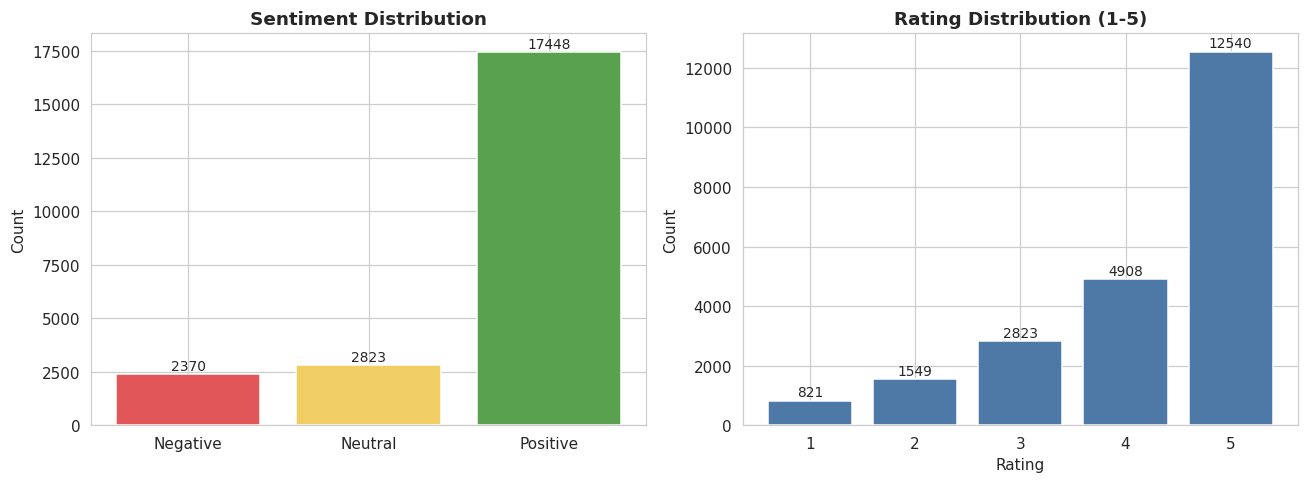

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Sentiment distribution
ax = axes[0]
order_counts = df["Sentiment"].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(CLASS_ORDER, order_counts.values, color=[PALETTE[c] for c in CLASS_ORDER])
ax.set_title("Sentiment Distribution")
ax.set_ylabel("Count")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50, f"{int(b.get_height())}",
            ha="center", va="bottom", fontsize=9)

# 2. Rating distribution
ax = axes[1]
rating_counts = df["Rating"].value_counts().sort_index()
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#4E79A7")
ax.set_title("Rating Distribution (1-5)")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50, f"{int(b.get_height())}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

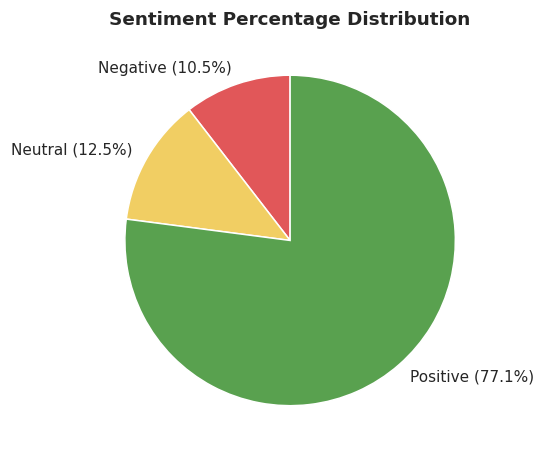

In [12]:
# 3. Sentiment percentage distribution
plt.figure(figsize=(5, 5))
pct_vals = df["Sentiment"].value_counts(normalize=True).reindex(CLASS_ORDER) * 100
plt.pie(pct_vals, labels=[f"{c} ({p:.1f}%)" for c, p in zip(CLASS_ORDER, pct_vals)],
        colors=[PALETTE[c] for c in CLASS_ORDER], startangle=90)
plt.title("Sentiment Percentage Distribution")
plt.tight_layout()
plt.show()

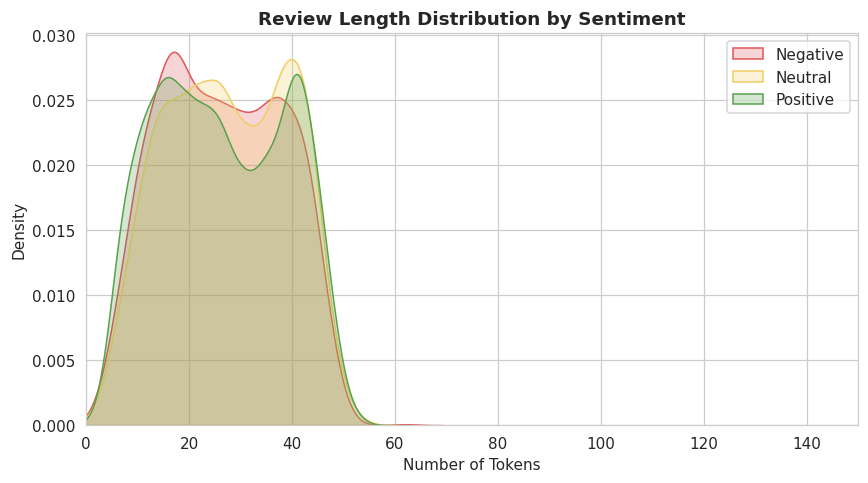

In [13]:
# 4. Review length distribution by sentiment
plt.figure(figsize=(8, 4.5))
for c in CLASS_ORDER:
    sns.kdeplot(df.loc[df["Sentiment"] == c, "Review_Length"], label=c, color=PALETTE[c], fill=True, alpha=0.25)
plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Number of Tokens")
plt.xlim(0, 150)
plt.legend()
plt.tight_layout()
plt.show()

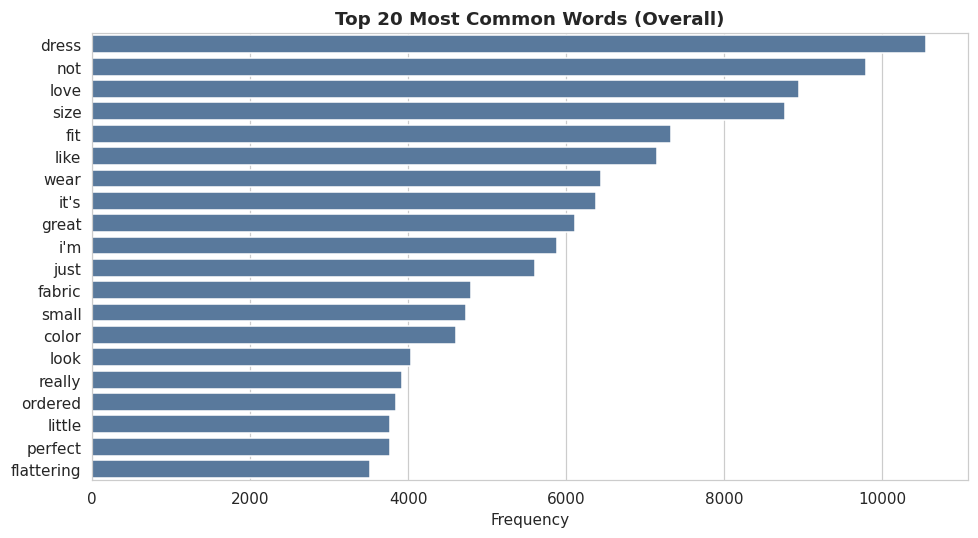

In [14]:
# 5. Most common words overall
all_words = [w for toks in df["Tokens"] for w in toks]
top_overall = Counter(all_words).most_common(20)
words, freqs = zip(*top_overall)

plt.figure(figsize=(9, 5))
sns.barplot(x=list(freqs), y=list(words), color="#4E79A7")
plt.title("Top 20 Most Common Words (Overall)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

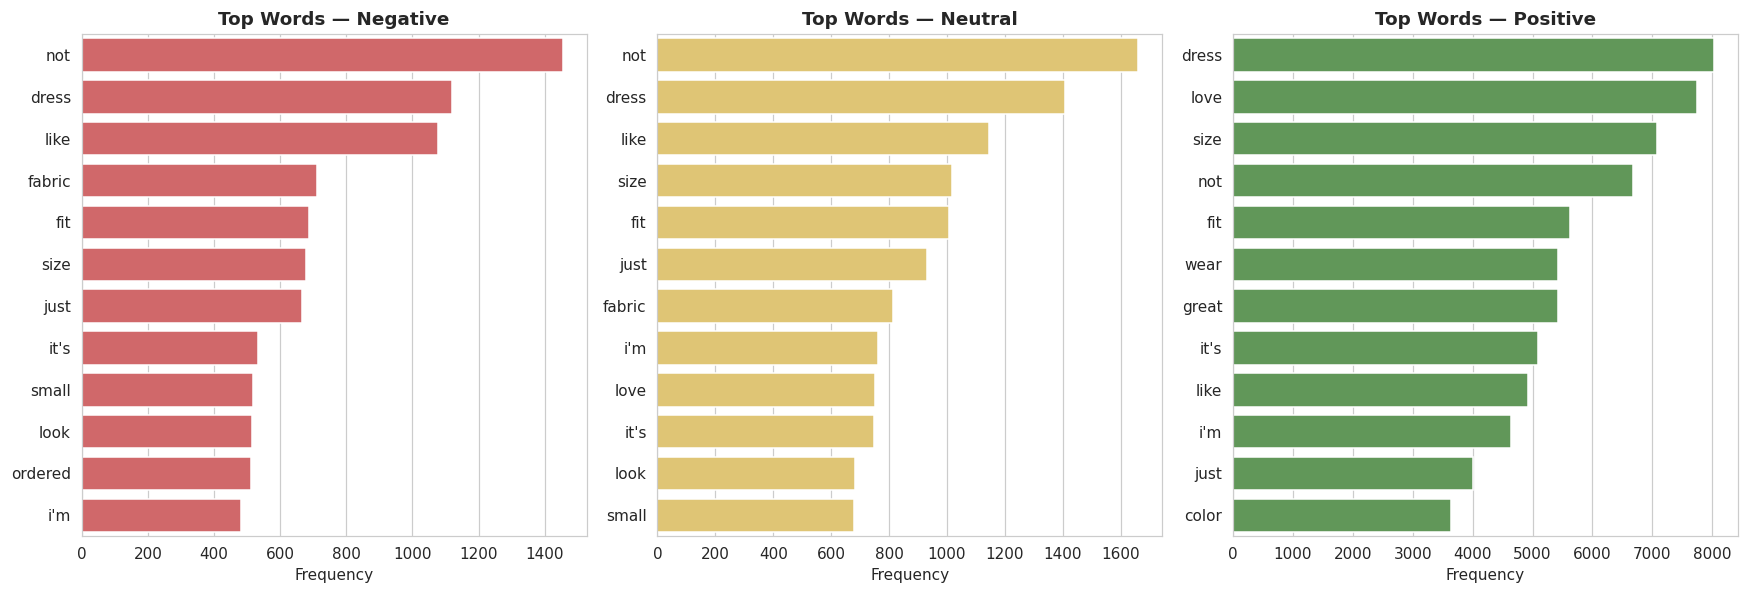

In [15]:
# 6. Most common words per sentiment
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, c in zip(axes, CLASS_ORDER):
    words_c = [w for toks in df.loc[df["Sentiment"] == c, "Tokens"] for w in toks]
    top_c = Counter(words_c).most_common(12)
    w, f = zip(*top_c)
    sns.barplot(x=list(f), y=list(w), ax=ax, color=PALETTE[c])
    ax.set_title(f"Top Words — {c}")
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

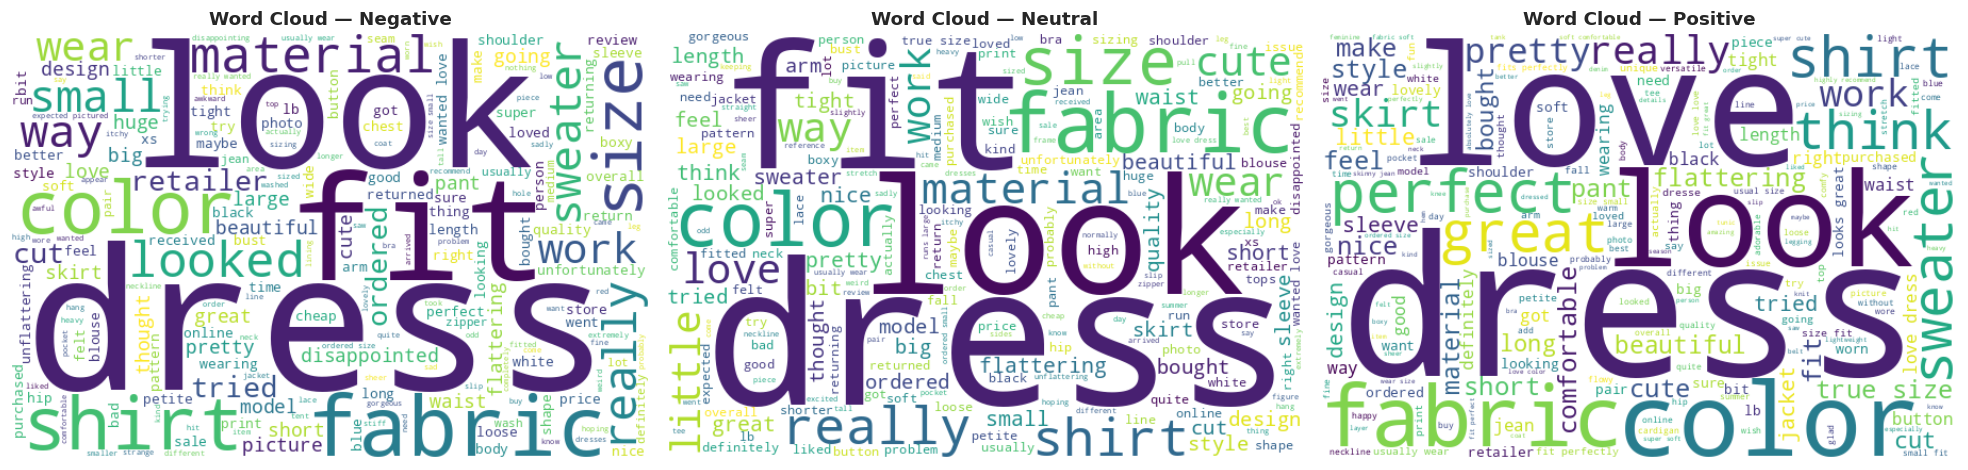

In [16]:
# 7. Word clouds per sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, c in zip(axes, CLASS_ORDER):
    text_c = " ".join(df.loc[df["Sentiment"] == c, "Processed_Review"])
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", random_state=RANDOM_STATE).generate(text_c)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Word Cloud — {c}")
    ax.axis("off")
plt.tight_layout()
plt.show()

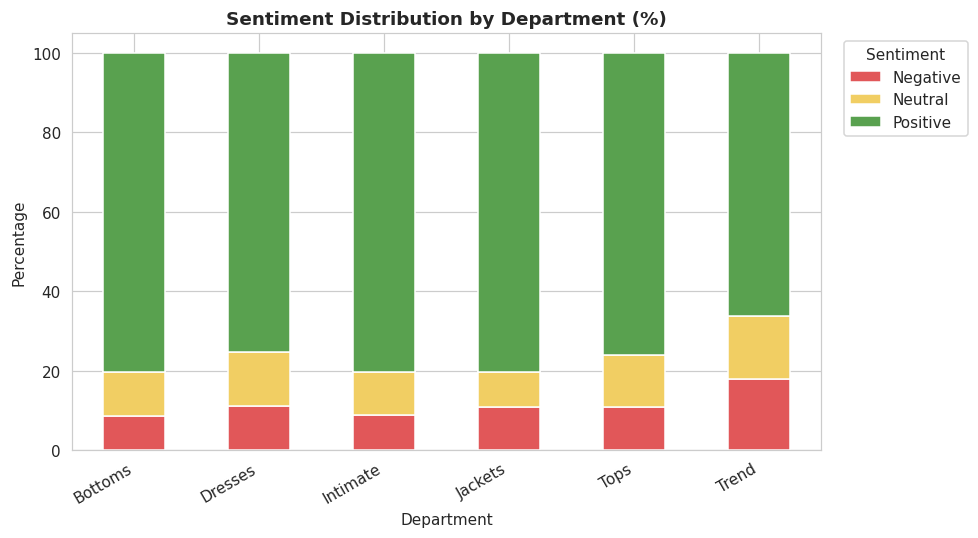

In [17]:
# 8. Sentiment distribution by Department Name
dept_sentiment = pd.crosstab(df["Department Name"], df["Sentiment"], normalize="index")[CLASS_ORDER] * 100

dept_sentiment.plot(kind="bar", stacked=True, figsize=(9, 5),
                     color=[PALETTE[c] for c in CLASS_ORDER])
plt.title("Sentiment Distribution by Department (%)")
plt.ylabel("Percentage")
plt.xlabel("Department")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 9. Feature Preparation
Input `X` is the processed review text only. `Rating`, `Recommended IND`, `Positive Feedback Count`, `Age`, and
`Clothing ID` are **excluded** — the model must predict sentiment from text, not from metadata that leaks the label.

In [18]:
X = df["Processed_Review"]
y = df["Sentiment"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (22641,)
y distribution:
 Sentiment
Positive    17448
Neutral      2823
Negative     2370
Name: count, dtype: int64


## 10. Train/Test Split
Split **before** fitting TF-IDF to prevent data leakage. `stratify=y` keeps the same class proportions
in both train and test sets, which matters given the class imbalance.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print()
print("Train distribution:\n", y_train.value_counts(normalize=True).round(3))
print()
print("Test distribution:\n", y_test.value_counts(normalize=True).round(3))

Train size: 18112
Test size : 4529

Train distribution:
 Sentiment
Positive    0.771
Neutral     0.125
Negative    0.105
Name: proportion, dtype: float64

Test distribution:
 Sentiment
Positive    0.771
Neutral     0.125
Negative    0.105
Name: proportion, dtype: float64


## 11. TF-IDF Vectorization
Fit TF-IDF **only** on the training set, then transform the test set with the same vectorizer — this avoids
any information from the test set leaking into the vocabulary or IDF weights.

In [20]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit ONLY on train
X_test_tfidf = tfidf.transform(X_test)         # transform test with train vocabulary

print("Train TF-IDF matrix shape:", X_train_tfidf.shape)
print("Test TF-IDF matrix shape :", X_test_tfidf.shape)

Train TF-IDF matrix shape: (18112, 20000)
Test TF-IDF matrix shape : (4529, 20000)


## 12. Handle Class Imbalance
Positive reviews dominate the dataset. Two complementary strategies are used:

- **`class_weight="balanced"`** for algorithms that support it — the natural, leak-free baseline approach.
- **`RandomOverSampler`** as an optional experiment, applied **only to the training TF-IDF matrix** (never the test set).
  Standard SMOTE is avoided here since interpolating between sparse high-dimensional TF-IDF vectors produces
  low-quality synthetic samples; `RandomOverSampler` (simple duplication) works safely with sparse text data.

In [21]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_tfidf_ros, y_train_ros = ros.fit_resample(X_train_tfidf, y_train)

print("Original training distribution:\n", y_train.value_counts())
print()
print("After RandomOverSampler:\n", y_train_ros.value_counts())

Original training distribution:
 Sentiment
Positive    13958
Neutral      2258
Negative     1896
Name: count, dtype: int64

After RandomOverSampler:
 Sentiment
Positive    13958
Neutral     13958
Negative    13958
Name: count, dtype: int64


## 13. Models Dictionary
A single dictionary of models suited to TF-IDF text classification. `class_weight="balanced"` is applied only
where supported (Logistic Regression, Linear SVM, SGD, Random Forest, Extra Trees, Decision Tree) — Naive Bayes
variants don't support it and are trained as-is on the original (non-oversampled) training data.

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Complement Naive Bayes": ComplementNB(),
    "SGD Classifier": SGDClassifier(class_weight="balanced", random_state=RANDOM_STATE, loss="hinge"),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, class_weight="balanced",
                                         random_state=RANDOM_STATE, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
}

list(models.keys())

['Logistic Regression',
 'Linear SVM',
 'Multinomial Naive Bayes',
 'Complement Naive Bayes',
 'SGD Classifier',
 'Random Forest',
 'Extra Trees',
 'Decision Tree']

## 14. Train All Models
Loop over the models dictionary: train on the original (imbalance-aware via `class_weight`) training set,
predict on the held-out test set, and store results — no repeated per-model code.

In [23]:
results = []
predictions = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    predictions[name] = y_pred
    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })
    print(f"Trained: {name}")

results_df = pd.DataFrame(results)
results_df

Trained: Logistic Regression


Trained: Linear SVM
Trained: Multinomial Naive Bayes
Trained: Complement Naive Bayes


Trained: SGD Classifier


Trained: Random Forest


Trained: Extra Trees


Trained: Decision Tree


,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,0.791565,0.824777,0.791565,0.805577,0.614376
1,Linear SVM,0.810996,0.802861,0.810996,0.806702,0.593194
2,Multinomial Naive Bayes,0.775889,0.727294,0.775889,0.684056,0.322636
3,Complement Naive Bayes,0.825789,0.808191,0.825789,0.814778,0.609715
4,SGD Classifier,0.816957,0.813695,0.816957,0.815054,0.613982
5,Random Forest,0.788253,0.744086,0.788253,0.712333,0.393993
6,Extra Trees,0.790903,0.734893,0.790903,0.718256,0.407317
7,Decision Tree,0.704129,0.726597,0.704129,0.714547,0.474502


## 15. Evaluation Metrics
Accuracy alone is misleading on imbalanced data. **Macro F1** weighs all three classes equally, so it's the
key metric here. Full per-class classification reports are shown for every model.

In [24]:
for name in models.keys():
    print(f"===== {name} =====")
    print(classification_report(y_test, predictions[name], labels=CLASS_ORDER, zero_division=0))
    print()

===== Logistic Regression =====
              precision    recall  f1-score   support

    Negative       0.50      0.60      0.55       474
     Neutral       0.34      0.45      0.39       565
    Positive       0.95      0.87      0.91      3490

    accuracy                           0.79      4529
   macro avg       0.60      0.64      0.61      4529
weighted avg       0.82      0.79      0.81      4529


===== Linear SVM =====
              precision    recall  f1-score   support

    Negative       0.52      0.51      0.52       474
     Neutral       0.36      0.32      0.34       565
    Positive       0.91      0.93      0.92      3490

    accuracy                           0.81      4529
   macro avg       0.60      0.59      0.59      4529
weighted avg       0.80      0.81      0.81      4529


===== Multinomial Naive Bayes =====
              precision    recall  f1-score   support

    Negative       0.73      0.04      0.08       474
     Neutral       0.42      0.01   

              precision    recall  f1-score   support

    Negative       0.71      0.19      0.30       474
     Neutral       0.38      0.02      0.04       565
    Positive       0.80      1.00      0.89      3490

    accuracy                           0.79      4529
   macro avg       0.63      0.40      0.41      4529
weighted avg       0.73      0.79      0.72      4529


===== Decision Tree =====


              precision    recall  f1-score   support

    Negative       0.30      0.32      0.31       474
     Neutral       0.25      0.31      0.27       565
    Positive       0.86      0.82      0.84      3490

    accuracy                           0.70      4529
   macro avg       0.47      0.48      0.47      4529
weighted avg       0.73      0.70      0.71      4529




## 16. Model Comparison
Models ranked by **Macro F1** (not Accuracy) — the fairer metric given the class imbalance.

In [25]:
comparison_df = results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,0.791565,0.824777,0.791565,0.805577,0.614376
1,SGD Classifier,0.816957,0.813695,0.816957,0.815054,0.613982
2,Complement Naive Bayes,0.825789,0.808191,0.825789,0.814778,0.609715
3,Linear SVM,0.810996,0.802861,0.810996,0.806702,0.593194
4,Decision Tree,0.704129,0.726597,0.704129,0.714547,0.474502
5,Extra Trees,0.790903,0.734893,0.790903,0.718256,0.407317
6,Random Forest,0.788253,0.744086,0.788253,0.712333,0.393993
7,Multinomial Naive Bayes,0.775889,0.727294,0.775889,0.684056,0.322636


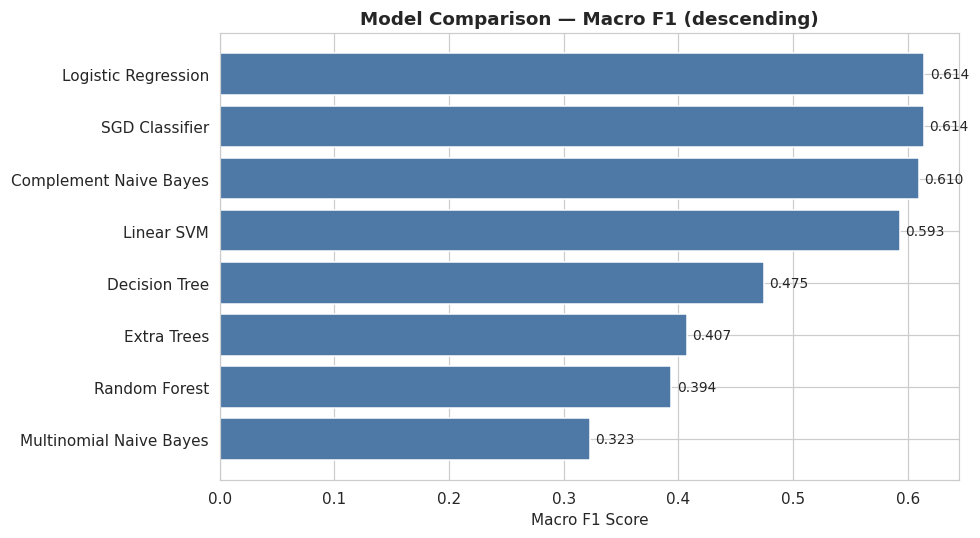

In [26]:
plt.figure(figsize=(9, 5))
order = comparison_df["Model"]
bars = plt.barh(order, comparison_df["Macro F1"], color="#4E79A7")
plt.gca().invert_yaxis()
plt.xlabel("Macro F1 Score")
plt.title("Model Comparison — Macro F1 (descending)")
for b in bars:
    plt.text(b.get_width() + 0.005, b.get_y() + b.get_height()/2, f"{b.get_width():.3f}",
              va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 17. Confusion Matrices
Confusion matrices for the **top 3 models** by Macro F1, using a consistent class order (Negative, Neutral, Positive).

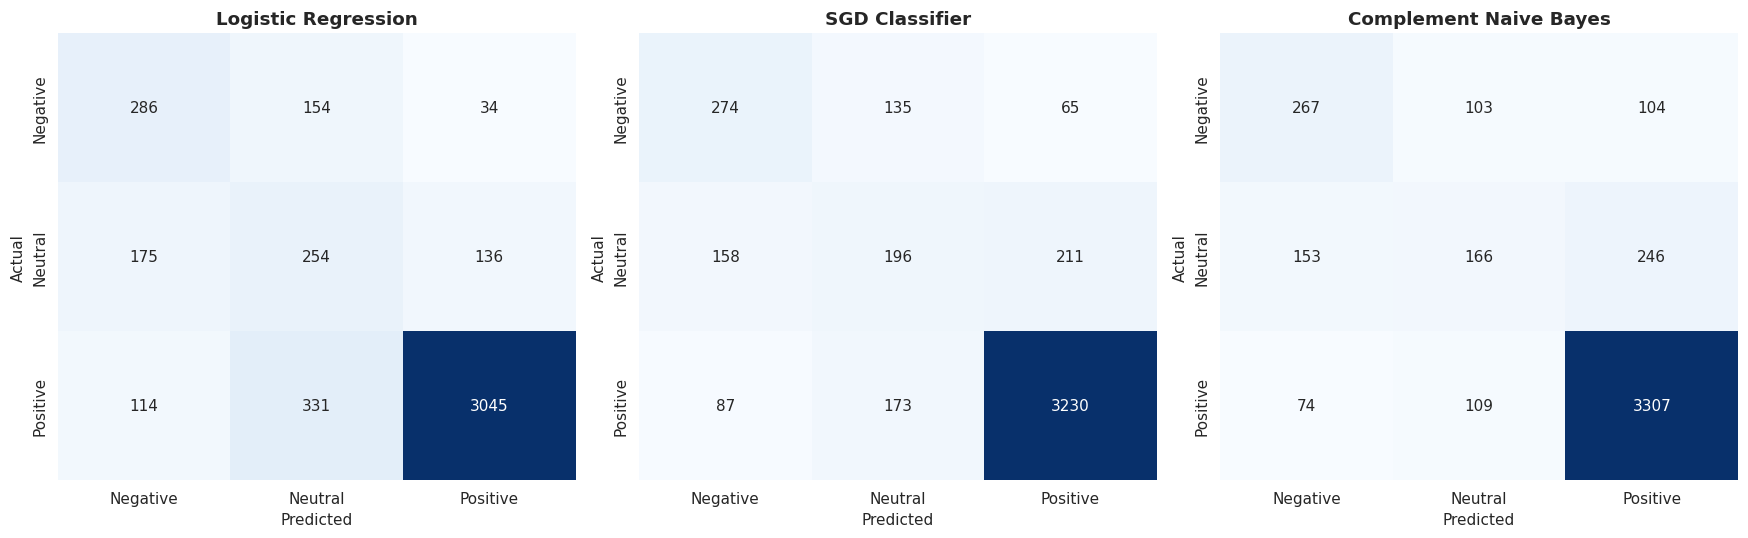

In [27]:
top3 = comparison_df["Model"].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, predictions[name], labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 18. Best Model
The best model is selected automatically by **Macro F1**.

In [28]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]
best_row = comparison_df.iloc[0]

print(f"Best Model: {best_model_name}\n")
print(f"Accuracy    : {best_row['Accuracy']:.4f}")
print(f"Precision   : {best_row['Precision']:.4f}")
print(f"Recall      : {best_row['Recall']:.4f}")
print(f"Weighted F1 : {best_row['Weighted F1']:.4f}")
print(f"Macro F1    : {best_row['Macro F1']:.4f}")

Best Model: Logistic Regression

Accuracy    : 0.7916
Precision   : 0.8248
Recall      : 0.7916
Weighted F1 : 0.8056
Macro F1    : 0.6144


In [29]:
print(classification_report(y_test, best_pred, labels=CLASS_ORDER, zero_division=0))

              precision    recall  f1-score   support

    Negative       0.50      0.60      0.55       474
     Neutral       0.34      0.45      0.39       565
    Positive       0.95      0.87      0.91      3490

    accuracy                           0.79      4529
   macro avg       0.60      0.64      0.61      4529
weighted avg       0.82      0.79      0.81      4529



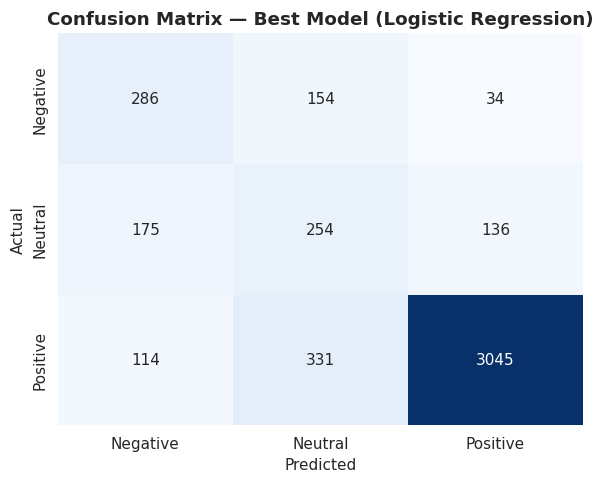

In [30]:
cm_best = confusion_matrix(y_test, best_pred, labels=CLASS_ORDER)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title(f"Confusion Matrix — Best Model ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**Why this model?** It achieves the highest Macro F1 — meaning it balances performance across Negative, Neutral, *and* Positive classes rather than just favoring the majority (Positive) class, which is what matters most on this imbalanced dataset.

## 19. Error Analysis
Inspect misclassified reviews for the best model to understand common failure patterns.

In [31]:
test_df = pd.DataFrame({
    "Review Text": X_test.values,
    "Actual": y_test.values,
    "Predicted": best_pred
})

errors_df = test_df[test_df["Actual"] != test_df["Predicted"]].reset_index(drop=True)
print(f"Total misclassified: {len(errors_df)} out of {len(test_df)} ({len(errors_df)/len(test_df):.1%})")
errors_df.sample(min(10, len(errors_df)), random_state=RANDOM_STATE)

Total misclassified: 944 out of 4529 (20.8%)


,Review Text,Actual,Predicted
96,saw local retailer store thought super cute tr...,Neutral,Positive
265,wanted love dress sadly returning color looked...,Neutral,Negative
811,flatter right body type sized medium normally ...,Positive,Negative
23,sweater amazing color vibrant quality high sup...,Positive,Neutral
30,dark blue adore read reviews later pondering b...,Positive,Negative
280,quick notes not sheer like previous poster ask...,Positive,Neutral
569,skirt comfortable pictured ran tts i'm tall we...,Negative,Neutral
259,loved color style sleeves bit short thought lo...,Positive,Neutral
331,omg never pay price shirt it's just shirt exce...,Positive,Negative
323,read prior reviews decided forward purchase pl...,Neutral,Positive


In [32]:
confusion_pairs = errors_df.groupby(["Actual", "Predicted"]).size().sort_values(ascending=False)
print("Most common confusion pairs:")
confusion_pairs.head(6)

Most common confusion pairs:


Actual    Predicted
Positive  Neutral      331
Neutral   Negative     175
Negative  Neutral      154
Neutral   Positive     136
Positive  Negative     114
Negative  Positive      34
dtype: int64

The confusion matrix and pairs above typically show the most errors occurring between **Negative↔Neutral** and
**Neutral↔Positive** — adjacent classes with overlapping, moderate language — rather than between the two extremes
(Negative vs Positive), which the model separates more clearly.

## 20. Save Model
Persist the best model and the fitted TF-IDF vectorizer for later reuse.

In [33]:
joblib.dump(best_model, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Saved: best_sentiment_model.pkl")
print("Saved: tfidf_vectorizer.pkl")

Saved: best_sentiment_model.pkl
Saved: tfidf_vectorizer.pkl


## 21. Final Conclusion

- **Best model:** see result above, selected by Macro F1.
- **Main challenge:** class imbalance (Positive reviews dominate) and overlapping language between adjacent
  sentiment classes (Negative/Neutral, Neutral/Positive).
- **Effect of imbalance:** Accuracy alone would over-favor the Positive class; Macro F1 gave a fairer comparison.
- **Key preprocessing:** text cleaning with negation preservation, stopword removal (keeping negations), TF-IDF
  (1–2 grams) fit only on training data.
- **Future improvements:** word embeddings / transformer-based models (e.g. BERT), richer negation-aware features,
  hyperparameter tuning, and more training data for the Neutral class.

## 22. Product Recommendation System

The sentiment model above works at the **review level**. This section builds a
**product-level** recommendation system on top of it — the kind of lookup a
shopper (or a merchandising team) would use on a site like SHEIN:

> *"I have a `Clothing ID` — is this specific product recommended based on its
> customers' ratings, historical recommendation rate, and review sentiment?"*

This is **not** a second trained model. It is a transparent, rule-based system
that aggregates:

1. **Historical Rating** — average `Rating` for the product.
2. **Historical Recommendation Rate** — % of reviewers who set `Recommended IND = 1`.
3. **Predicted Sentiment Mix** — every review for the product is passed through
   the *existing* fitted `tfidf` vectorizer (`transform`, never `fit_transform`)
   and the *existing* `best_model`, using the exact same cleaning /
   tokenization pipeline defined in Sections 6–7 (`clean_text`,
   `tokenize_and_filter`, `Processed_Review`).

```
User enters Clothing ID
        |
Find all reviews for this product
        |
Analyze Ratings -> Average Rating
        |
Recommended IND -> Recommendation Rate
        |
Review Text -> existing TF-IDF -> existing Best Model -> Sentiment %
        |
Combine into a transparent rule
        |
Recommended / Not Recommended
```

`Recommended IND` is used only to report the product's **historical**
recommendation rate and in the final rule — it is never fed into the
sentiment model, which continues to use text features only.

### 22.1 Product Search & Analysis Function

`analyze_product(clothing_id)` looks up every review for a product in the
**existing** `df`, computes rating / recommendation statistics, scores the
reviews with the **existing** `tfidf` + `best_model`, and applies a simple,
explainable rule:

```
Recommended if:
    Average Rating          >= 4
    AND Recommendation Rate >= 70%
    AND Positive Sentiment  >  Negative Sentiment
Otherwise: Not Recommended
```

This is a **Rule-Based Product Recommendation** — a transparent aggregation of
the statistics above, not a separately trained ML classifier.

In [34]:
def analyze_product(clothing_id, plot=True, verbose=True):
    """
    Look up all reviews for `clothing_id` in the existing `df`, compute
    rating / recommendation-rate / sentiment statistics using the EXISTING
    fitted `tfidf` vectorizer and `best_model`, and apply a transparent
    rule-based Recommended / Not Recommended decision.

    Returns a dict of the computed statistics, or None if the ID is not found.
    """
    product_df = df[df["Clothing ID"] == clothing_id]

    if product_df.empty:
        print(f"No reviews found for Clothing ID {clothing_id}. "
              f"Please check the ID and try again.")
        return None

    # ---- 1. Rating statistics ----
    n_reviews = len(product_df)
    avg_rating = product_df["Rating"].mean()

    # ---- 2. Historical recommendation rate (Recommended IND) ----
    rec_rate = product_df["Recommended IND"].mean() * 100
    not_rec_rate = 100 - rec_rate

    # ---- 3. Sentiment analysis using the EXISTING model + vectorizer ----
    # Reuses Processed_Review, which was built with the SAME clean_text /
    # tokenize_and_filter pipeline used to train the sentiment model.
    product_tfidf = tfidf.transform(product_df["Processed_Review"])   # transform only, never fit
    sentiment_preds = best_model.predict(product_tfidf)

    sentiment_counts = pd.Series(sentiment_preds).value_counts()
    sentiment_pct = (sentiment_counts / n_reviews * 100).reindex(CLASS_ORDER).fillna(0)

    positive_pct = sentiment_pct["Positive"]
    neutral_pct = sentiment_pct["Neutral"]
    negative_pct = sentiment_pct["Negative"]

    # ---- 4. Rule-Based Final Recommendation ----
    is_recommended = (avg_rating >= 4) and (rec_rate >= 70) and (positive_pct > negative_pct)
    final_label = "Recommended" if is_recommended else "Not Recommended"

    # ---- 5. Professional output ----
    if verbose:
        print("=" * 50)
        print("          PRODUCT RECOMMENDATION")
        print("=" * 50)
        print()
        print(f"Clothing ID: {clothing_id}")
        print()
        print("Product Statistics")
        print("-" * 18)
        print(f"Number of Reviews: {n_reviews}")
        print(f"Average Rating: {avg_rating:.2f} / 5")
        print()
        print("Recommendation")
        print("-" * 14)
        print(f"Recommended: {rec_rate:.2f}%")
        print(f"Not Recommended: {not_rec_rate:.2f}%")
        print()
        print("Sentiment Analysis")
        print("-" * 18)
        print(f"Positive: {positive_pct:.2f}%")
        print(f"Neutral: {neutral_pct:.2f}%")
        print(f"Negative: {negative_pct:.2f}%")
        print()
        print("-" * 50)
        print("FINAL RECOMMENDATION")
        print("-" * 50)
        print()
        print("Rule-Based Product Recommendation:")
        print("✅ RECOMMENDED" if is_recommended else "❌ NOT RECOMMENDED")
        print()

    if plot:
        _plot_product_analysis(clothing_id, product_df, sentiment_pct, rec_rate, not_rec_rate)

    return {
        "clothing_id": clothing_id,
        "n_reviews": n_reviews,
        "avg_rating": avg_rating,
        "recommend_rate_pct": rec_rate,
        "not_recommend_rate_pct": not_rec_rate,
        "positive_pct": positive_pct,
        "neutral_pct": neutral_pct,
        "negative_pct": negative_pct,
        "final_recommendation": final_label,
    }


def _plot_product_analysis(clothing_id, product_df, sentiment_pct, rec_rate, not_rec_rate):
    """Rating / Sentiment / Recommendation visualizations for one product."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. Rating distribution (1-5 stars)
    ax = axes[0]
    rating_counts = product_df["Rating"].value_counts().reindex([1, 2, 3, 4, 5]).fillna(0)
    ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#4E79A7")
    ax.set_title(f"Rating Distribution\nClothing ID {clothing_id}")
    ax.set_xlabel("Rating (Stars)")
    ax.set_ylabel("Number of Reviews")

    # 2. Predicted sentiment distribution
    ax = axes[1]
    sent_vals = [sentiment_pct.get(c, 0) for c in CLASS_ORDER]
    colors = [PALETTE[c] for c in CLASS_ORDER]
    bars = ax.bar(CLASS_ORDER, sent_vals, color=colors)
    ax.set_title("Predicted Sentiment (%)")
    ax.set_ylabel("Percentage")
    ax.set_ylim(0, 100)
    for b, v in zip(bars, sent_vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)

    # 3. Historical customer recommendation
    ax = axes[2]
    ax.pie([rec_rate, not_rec_rate], labels=["Recommended", "Not Recommended"],
           autopct="%1.1f%%", colors=["#59A14F", "#E15759"], startangle=90)
    ax.set_title("Customer Recommendation")

    plt.tight_layout()
    plt.show()


### 22.2 Test With a Real Product

Testing on the most-reviewed `Clothing ID` in the dataset, so every statistic
below is computed from real reviews (no hard-coded numbers).

Most-reviewed Clothing ID in the dataset: 1078

          PRODUCT RECOMMENDATION

Clothing ID: 1078

Product Statistics
------------------
Number of Reviews: 987
Average Rating: 4.19 / 5

Recommendation
--------------
Recommended: 81.76%
Not Recommended: 18.24%

Sentiment Analysis
------------------
Positive: 70.31%
Neutral: 18.03%
Negative: 11.65%

--------------------------------------------------
FINAL RECOMMENDATION
--------------------------------------------------

Rule-Based Product Recommendation:
✅ RECOMMENDED



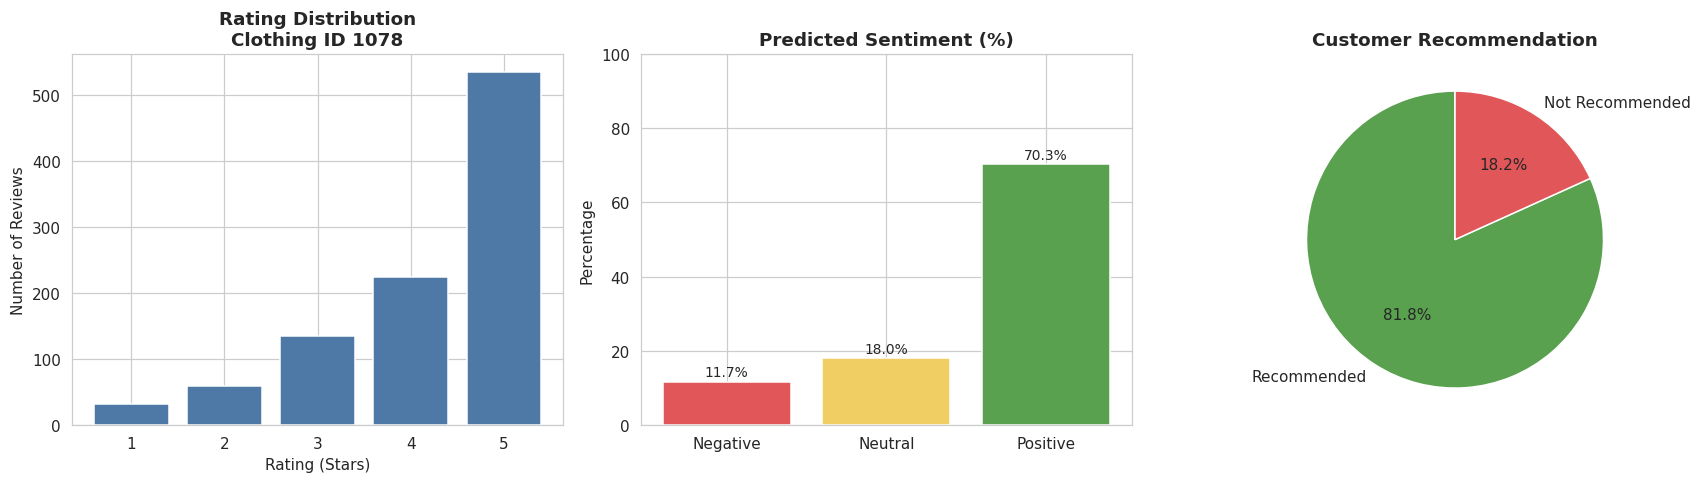

{'clothing_id': np.int64(1078),
 'n_reviews': 987,
 'avg_rating': np.float64(4.189463019250253),
 'recommend_rate_pct': np.float64(81.7629179331307),
 'not_recommend_rate_pct': np.float64(18.237082066869306),
 'positive_pct': np.float64(70.31408308004052),
 'neutral_pct': np.float64(18.034447821681866),
 'negative_pct': np.float64(11.651469098277609),
 'final_recommendation': 'Recommended'}

In [35]:
# Use a real, high-volume Clothing ID from the dataset for a first demonstration
example_clothing_id = df["Clothing ID"].value_counts().idxmax()
print(f"Most-reviewed Clothing ID in the dataset: {example_clothing_id}")
print()

result = analyze_product(example_clothing_id)
result


### 22.3 Interactive Product Search

Enter any `Clothing ID` to get its recommendation. When run in an interactive
Jupyter session, this cell prompts for input; if no interactive stdin is
available (e.g. batch execution), it falls back to a second real example ID so
the cell still runs end-to-end.

(No interactive input detected — using example Clothing ID 1094)
          PRODUCT RECOMMENDATION

Clothing ID: 1094

Product Statistics
------------------
Number of Reviews: 735
Average Rating: 4.19 / 5

Recommendation
--------------
Recommended: 82.04%
Not Recommended: 17.96%

Sentiment Analysis
------------------
Positive: 68.57%
Neutral: 19.46%
Negative: 11.97%

--------------------------------------------------
FINAL RECOMMENDATION
--------------------------------------------------

Rule-Based Product Recommendation:
✅ RECOMMENDED



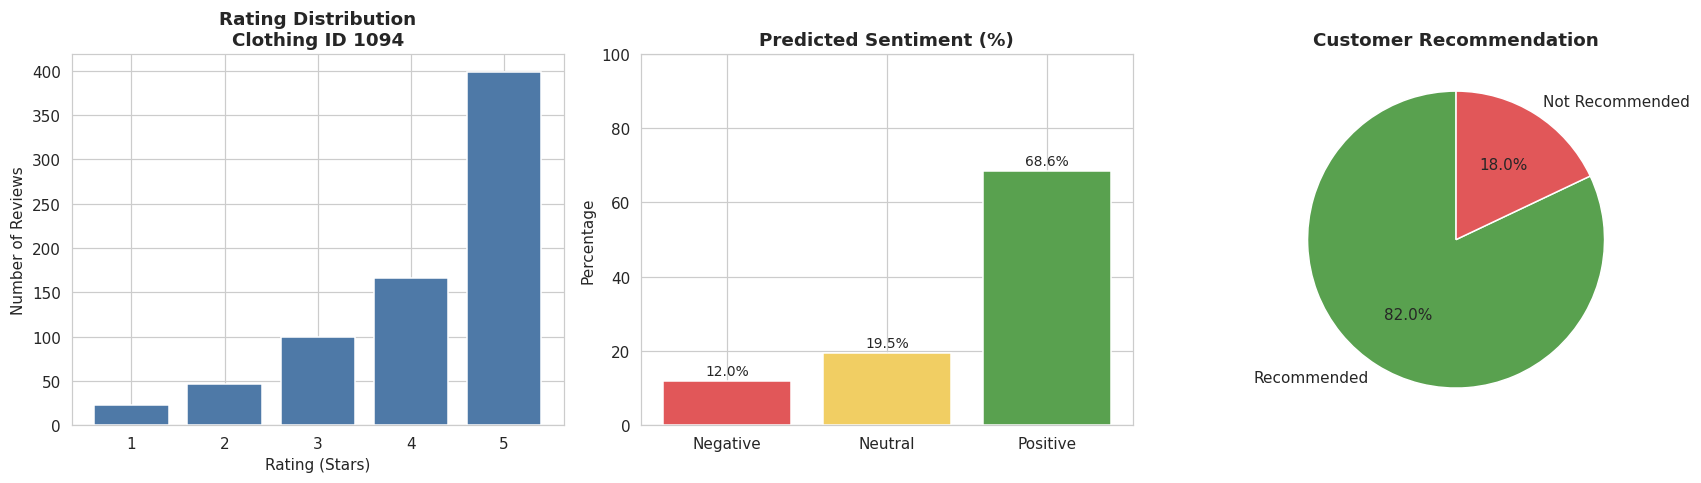

{'clothing_id': 1094,
 'n_reviews': 735,
 'avg_rating': np.float64(4.185034013605442),
 'recommend_rate_pct': np.float64(82.0408163265306),
 'not_recommend_rate_pct': np.float64(17.959183673469397),
 'positive_pct': np.float64(68.57142857142857),
 'neutral_pct': np.float64(19.45578231292517),
 'negative_pct': np.float64(11.972789115646258),
 'final_recommendation': 'Recommended'}

In [36]:
try:
    clothing_id = int(input("Enter Clothing ID: "))
except Exception:
    # Fallback for non-interactive execution — still a real ID from the dataset
    clothing_id = int(df["Clothing ID"].value_counts().index[2])
    print(f"(No interactive input detected — using example Clothing ID {clothing_id})")

analyze_product(clothing_id)


## 23. Final Conclusion (Updated)

- **Sentiment model:** unchanged from Section 21 — best model selected by Macro F1,
  saved as `best_sentiment_model.pkl` / `tfidf_vectorizer.pkl`.
- **Product Recommendation System:** a transparent, rule-based layer on top of the
  existing sentiment model. For any `Clothing ID` it combines the historical
  average rating, the historical `Recommended IND` rate, and the *predicted*
  sentiment mix (via `tfidf.transform` + `best_model.predict`, no retraining) into
  a single **Recommended / Not Recommended** verdict.
- **Why rule-based:** the goal is an explainable business decision, not another
  classifier — every input to the rule is human-readable and auditable.
- **No data leakage:** `Recommended IND` is used only for the historical
  recommendation-rate statistic and the final rule; it is never used as a feature
  for the sentiment model, which still relies solely on `Processed_Review` text.
- **Future improvements:** weight the rule by review recency or helpfulness
  (`Positive Feedback Count`), add per-`Department`/`Class` recommendation
  benchmarks, and expose `analyze_product` through a small web app or API for
  live product lookups.